In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib 

import tensorflow as tf

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

In [8]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [9]:
print(df['ST_Slope'].value_counts())

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64


# Data Preprocessing

In [10]:
# One Hot Encoding
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG'], dtype=int)
df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
0,40,M,140,289,0,172,N,0.0,Up,0,0,1,0,0,0,1,0
1,49,F,160,180,0,156,N,1.0,Flat,1,0,0,1,0,0,1,0
2,37,M,130,283,0,98,N,0.0,Up,0,0,1,0,0,0,0,1
3,48,F,138,214,0,108,Y,1.5,Flat,1,1,0,0,0,0,1,0
4,54,M,150,195,0,122,N,0.0,Up,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,110,264,0,132,N,1.2,Flat,1,0,0,0,1,0,1,0
914,68,M,144,193,1,141,N,3.4,Flat,1,1,0,0,0,0,1,0
915,57,M,130,131,0,115,Y,1.2,Flat,1,1,0,0,0,0,1,0
916,57,F,130,236,0,174,N,0.0,Flat,1,0,1,0,0,1,0,0


In [11]:
# Label Encoding (1/0)
df['Sex'] = (df['Sex'] == 'M').astype(int)
df['ExerciseAngina'] = (df['ExerciseAngina'] == 'N').astype(int)

In [12]:
lE = LabelEncoder()
df['ST_Slope'] = lE.fit_transform(df['ST_Slope'])

In [13]:
df['ST_Slope'].value_counts()

ST_Slope
1    460
2    395
0     63
Name: count, dtype: int64

In [14]:
# dividing input and output
x = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [15]:
# Scalling
scalingModel = StandardScaler()
x = scalingModel.fit_transform(x)
joblib.dump(scalingModel, 'scaler.joblib')

['scaler.joblib']

In [16]:
# Over sampling
rOS = RandomOverSampler()
x, y = rOS.fit_resample(x, y)

In [17]:
cols = [col for col in df.columns if col != 'HeartDisease']
newCols = cols + ['HeartDisease']

data = np.hstack((x, np.reshape(y, (-1, 1))))
transformedData = pd.DataFrame(data, columns=newCols)

transformedData

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,HeartDisease
0,-1.433140,0.515952,0.410909,0.825070,-0.551341,1.382928,0.823556,-0.832432,1.052114,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.0
1,-0.478484,-1.938163,1.491752,-0.171961,-0.551341,0.754157,0.823556,0.105664,-0.596078,-1.084138,-0.481887,1.876744,-0.229679,-0.507478,0.814275,-0.490449,1.0
2,-1.751359,0.515952,-0.129513,0.770188,-0.551341,-1.525138,0.823556,-0.832432,1.052114,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,-1.228087,2.038947,0.0
3,-0.584556,-1.938163,0.302825,0.139040,-0.551341,-1.132156,-1.214246,0.574711,-0.596078,0.922392,-0.481887,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,1.0
4,0.051881,0.515952,0.951331,-0.034755,-0.551341,-0.581981,0.823556,-0.832432,1.052114,-1.084138,-0.481887,1.876744,-0.229679,-0.507478,0.814275,-0.490449,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,-0.160265,-1.938163,0.194740,-0.025608,-0.551341,1.265034,0.823556,-0.738623,-0.596078,-1.084138,-0.481887,1.876744,-0.229679,1.970528,-1.228087,-0.490449,0.0
1012,-0.584556,-1.938163,0.951331,0.257952,-0.551341,-0.267596,-1.214246,0.105664,-0.596078,0.922392,-0.481887,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.0
1013,0.900464,0.515952,0.140698,-0.546991,-0.551341,0.007491,0.823556,-0.644813,1.052114,-1.084138,-0.481887,-0.532838,4.353909,-0.507478,-1.228087,2.038947,0.0
1014,1.855120,-1.938163,1.491752,0.943982,-0.551341,0.989946,0.823556,-0.457194,1.052114,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.0


# Train, Val,  Test Split

In [18]:
xTrain, xTemp, yTrain, yTemp = train_test_split(
    x, y, test_size=0.4, random_state=0
)

In [19]:
xVal, xTest, yVal, yTest = train_test_split(
    xTemp, yTemp, test_size=0.5, random_state=0
)

# Model Training

In [20]:
nn = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'), 
    tf.keras.layers.Dense(16, activation='relu'), 
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [21]:
nn.compile(
    optimizer='adam',  
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

In [22]:
nn.evaluate(xTrain, yTrain)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5386 - loss: 0.7008  


[0.7007835507392883, 0.5385878682136536]

In [23]:
nn.evaluate(xVal, yVal)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5665 - loss: 0.6927 


[0.6926640272140503, 0.5665024518966675]

In [24]:
nn.fit(
    xTrain, yTrain, 
    batch_size=16, 
    epochs=40, 
    validation_data=(xVal, yVal)
)

Epoch 1/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6404 - loss: 0.6509 - val_accuracy: 0.7882 - val_loss: 0.6000
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7783 - loss: 0.5714 - val_accuracy: 0.8276 - val_loss: 0.5271
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8030 - loss: 0.5026 - val_accuracy: 0.8276 - val_loss: 0.4620
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8161 - loss: 0.4514 - val_accuracy: 0.8128 - val_loss: 0.4137
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8243 - loss: 0.4201 - val_accuracy: 0.8276 - val_loss: 0.3835
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8325 - loss: 0.4011 - val_accuracy: 0.8424 - val_loss: 0.3636
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8358 - loss: 0.3858 - val_accuracy: 0.8522 - val_loss: 0.3473
Epoch 8/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8374 - loss: 0.3762 - val_accuracy: 0.8473 - val_loss:

In [25]:
nn.evaluate(xTest, yTest)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8775 - loss: 0.3110 


[0.31103944778442383, 0.8774510025978088]

In [26]:
nn.save('heart.keras')

In [27]:
cleanedDataFrame = pd.DataFrame(np.hstack((x, np.reshape(y, (-1, 1)))),columns = [
    "Age",
    "Sex",
    "RestingBP",
    "Cholesterol",
    "FastingBS",
    "MaxHR",
    "ExerciseAngina",
    "Oldpeak",
    "ST_Slope",
    "HeartDisease",
    "ChestPainType_ASY",
    "ChestPainType_ATA",
    "ChestPainType_NAP",
    "ChestPainType_TA",
    "RestingECG_LVH",
    "RestingECG_Normal",
    "RestingECG_ST"
], index=None)

In [28]:
cleanedDataFrame

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
0,-1.433140,0.515952,0.410909,0.825070,-0.551341,1.382928,0.823556,-0.832432,1.052114,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.0
1,-0.478484,-1.938163,1.491752,-0.171961,-0.551341,0.754157,0.823556,0.105664,-0.596078,-1.084138,-0.481887,1.876744,-0.229679,-0.507478,0.814275,-0.490449,1.0
2,-1.751359,0.515952,-0.129513,0.770188,-0.551341,-1.525138,0.823556,-0.832432,1.052114,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,-1.228087,2.038947,0.0
3,-0.584556,-1.938163,0.302825,0.139040,-0.551341,-1.132156,-1.214246,0.574711,-0.596078,0.922392,-0.481887,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,1.0
4,0.051881,0.515952,0.951331,-0.034755,-0.551341,-0.581981,0.823556,-0.832432,1.052114,-1.084138,-0.481887,1.876744,-0.229679,-0.507478,0.814275,-0.490449,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1011,-0.160265,-1.938163,0.194740,-0.025608,-0.551341,1.265034,0.823556,-0.738623,-0.596078,-1.084138,-0.481887,1.876744,-0.229679,1.970528,-1.228087,-0.490449,0.0
1012,-0.584556,-1.938163,0.951331,0.257952,-0.551341,-0.267596,-1.214246,0.105664,-0.596078,0.922392,-0.481887,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.0
1013,0.900464,0.515952,0.140698,-0.546991,-0.551341,0.007491,0.823556,-0.644813,1.052114,-1.084138,-0.481887,-0.532838,4.353909,-0.507478,-1.228087,2.038947,0.0
1014,1.855120,-1.938163,1.491752,0.943982,-0.551341,0.989946,0.823556,-0.457194,1.052114,-1.084138,2.075177,-0.532838,-0.229679,-0.507478,0.814275,-0.490449,0.0


Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST'],
      dtype='str')


NameError: name 'column' is not defined

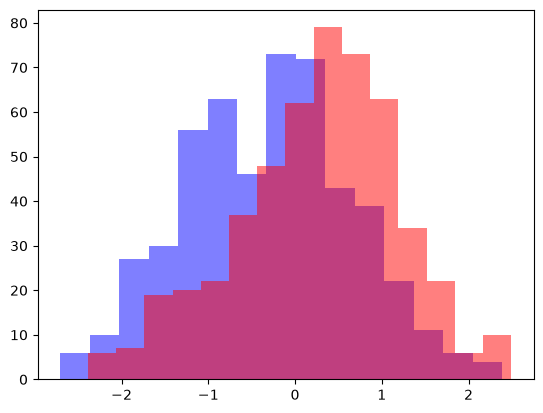

In [29]:
columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR']
print(transformedData.columns[:-1])

for i in range(len(transformedData.columns[:-1])):
    label = transformedData.columns[i]
    plt.hist(transformedData[transformedData['HeartDisease'] == 0][label], color='b', alpha=0.5, label='No Heart Disease', bins=15)
    plt.hist(transformedData[transformedData['HeartDisease'] == 1][label], color='r', alpha=0.5, label='Heart Disease', bins=15)
    
    # plt.scatter(
    #     df['HeartDisease'],
    #     df[column],
    #     alpha=0.5
    # )
    
    plt.title(f'Heart Disease vs {column}')
    plt.xlabel('Heart Disease')
    plt.ylabel(label)
    plt.legend()

    plt.show()


In [ ]:
cleanedDataFrame.to_csv('cleanedDataFrame.csv', index=False)

In [ ]:
cleanedDataFrame.isnull().sum()

Age                  0
Sex                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
ExerciseAngina       0
Oldpeak              0
ST_Slope             0
HeartDisease         0
ChestPainType_ASY    0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_LVH       0
RestingECG_Normal    0
RestingECG_ST        0
dtype: int64